<a href="https://colab.research.google.com/github/vikasverma9721/Machine-Learning-Models/blob/main/Linear_Regression_Stock_Market_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Import Libraries :***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.metrics import r2_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df1 = ('/content/drive/MyDrive/Dataset/Stock Market Analysis.csv')

***Read and review dataset :***

In [ ]:
df = pd.read_csv(df1)

In [ ]:
df.head()

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000


***Pre-Preccessing***

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Ticker     248 non-null    object 
 1   Date       248 non-null    object 
 2   Open       248 non-null    float64
 3   High       248 non-null    float64
 4   Low        248 non-null    float64
 5   Close      248 non-null    float64
 6   Adj Close  248 non-null    float64
 7   Volume     248 non-null    int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 15.6+ KB


In [ ]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,248.000000,248.000000,248.000000,248.000000,248.000000,2.480000e+02
mean,215.252093,217.919662,212.697452,215.381674,215.362697,3.208210e+07
std,91.691315,92.863023,90.147881,91.461989,91.454750,2.233590e+07
min,89.540001,90.129997,88.860001,89.349998,89.349998,2.657900e+06
25%,135.235004,137.440004,134.822495,136.347498,136.347498,1.714180e+07
50%,208.764999,212.614998,208.184998,209.920006,209.920006,2.734000e+07
75%,304.177505,307.565002,295.437500,303.942505,303.942505,4.771772e+07
max,372.410004,373.829987,361.739990,366.829987,366.829987,1.133164e+08


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
243,False
244,False
245,False
246,False


In [ ]:
df.isnull().sum()

,0
Ticker,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [ ]:
df.shape

(248, 8)

***Exploratory Dara Analysis***

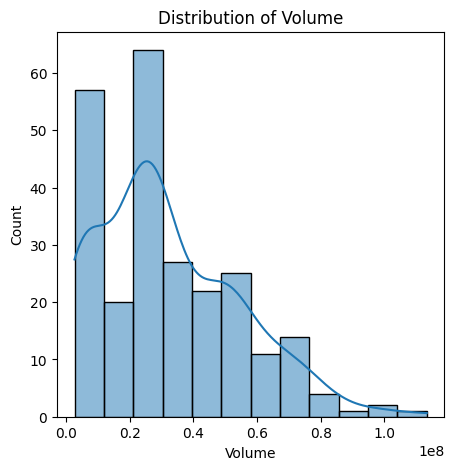

In [ ]:
plt.figure(figsize = (5,5))
sns.histplot(df['Volume'], kde = True)
plt.title("Distribution of Volume")
plt.show()

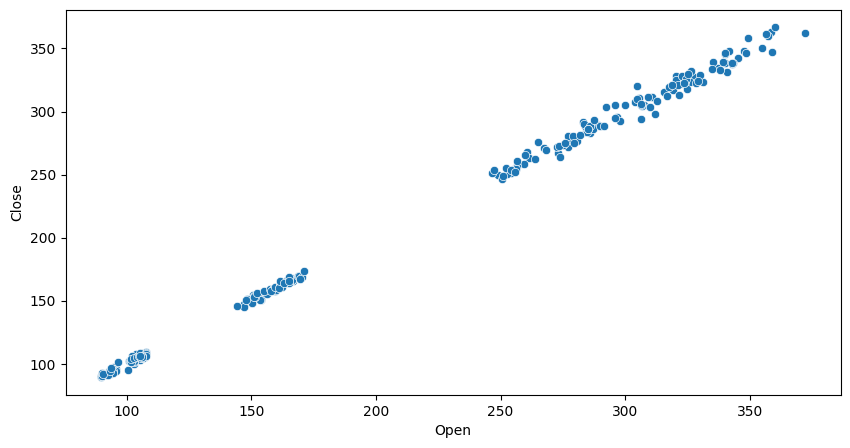

In [ ]:
plt.figure(figsize = (10,5))
sns.scatterplot(data = df, x = 'Open', y = 'Close')
plt.show()

<Axes: >

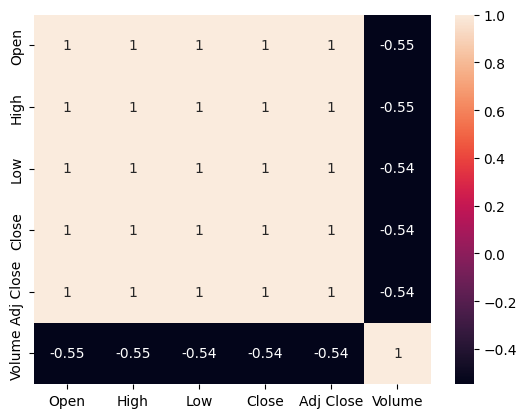

In [ ]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot = True)

***Pair Plot***

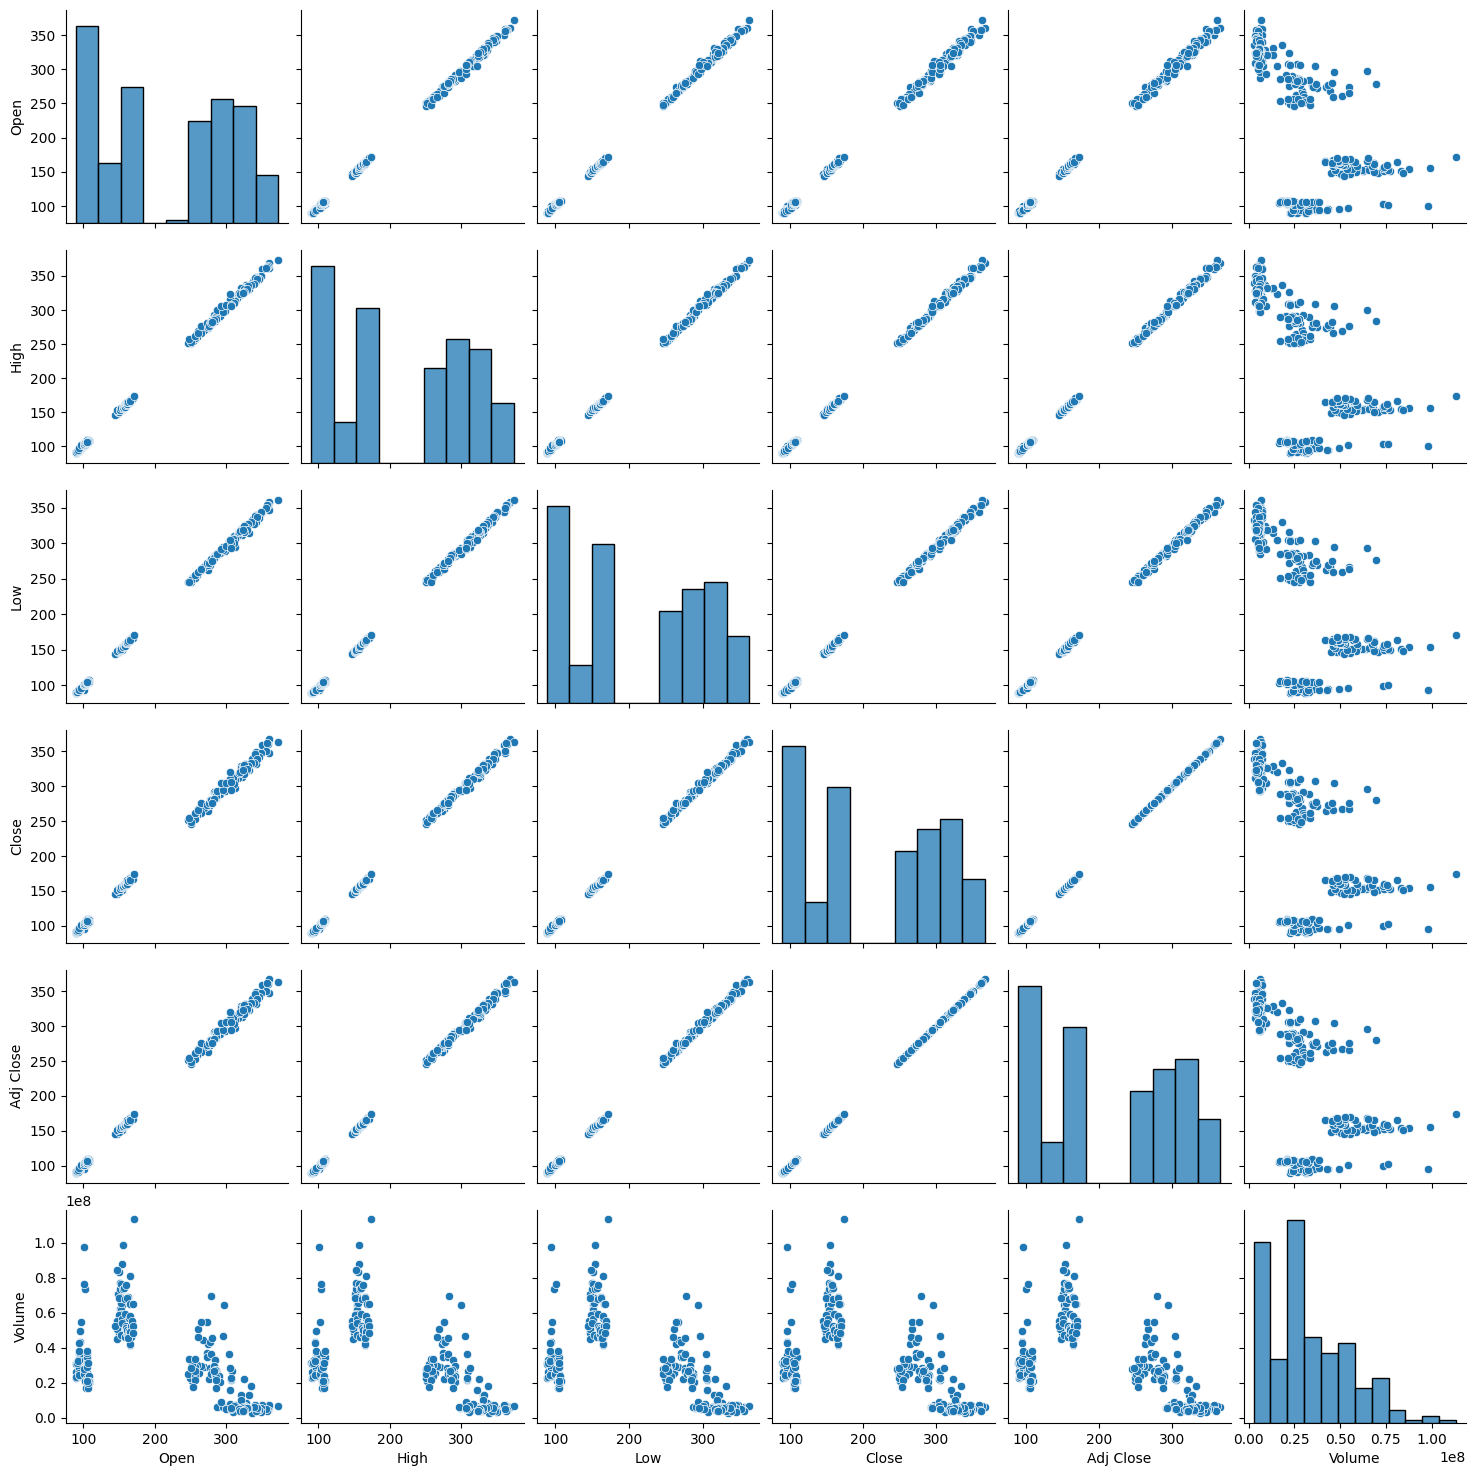

In [ ]:
sns.pairplot(df)

***Check Outliers in the Open Column :-***

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(x = df['Open'], bins = 10, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df['Open'])

***Check Outliers in the High Column.***

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(x = df['High'], bins = 10, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df['High'])

***Check Outliers in the Low Column.***

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(x = df['Low'], bins = 10, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df['Low'])

***Check Outliers in the Close Column.***

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(x = df['Close'], bins = 10, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df['Close'])

***Check outliers in the Adj Close Column.***

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(x = df['Adj Close'], bins = 10, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df['Adj Close'])

***Check Outliers in the Volume Column.***

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(x = df['Volume'], bins = 10, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df['Volume'])
plt.title("Volume Outliers")
plt.show()

***Remove Outliers from IQR Method in the Volume column.***

In [ ]:
percentile25 = df['Volume'].quantile(0.25)
percentile75 = df['Volume'].quantile(0.75)
print("Percentile25 =", percentile25)
print("Percentile75 =", percentile75)

In [ ]:
iqr = percentile75 - percentile25
print("IQR =", iqr)

In [ ]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Upper Limit =", upper_limit)
print("Lower Limit =", lower_limit)

In [ ]:
df[df['Volume'] > upper_limit]

In [ ]:
df[df['Volume'] < lower_limit]

***Trimming***

In [ ]:
new_df = df[(df['Volume'] < upper_limit) & (df['Volume'] > lower_limit)]

In [ ]:
new_df.shape

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.boxplot(x = df['Volume'])
plt.title("Before Outliers Removal")

plt.subplot(1,2,2)
sns.boxplot(x = new_df['Volume'])
plt.title("After Outliers Removal")
plt.show()

***Create Dummy Variable.***

In [ ]:
df_clean = pd.get_dummies(new_df,columns = ['Ticker'])
df_clean

In [ ]:
new_df.shape

In [ ]:
X = df_clean.drop(["Volume","Date"], axis = 1)
y = df_clean[["Volume"]]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

In [ ]:
y_predict = model.predict(X_test)

In [ ]:
accuracy = r2_score(y_test, y_predict)
print(f"Final Model Accuracy (R-squared): {accuracy:.2f}")

In [ ]:
print(model.score(X_train, y_train))

In [ ]:
print(model.score(X_test, y_test))

In [ ]:
n = int(input("Enter the prediction row number = "))
test_value = X_test.iloc[n]
real_value = y_test.iloc[n]
prediction = model.predict([test_value])
defference = abs(real_value[0] - prediction[0][0])
print(f"Prediction Row Number {n} Result")
print(f"Real Value = {real_value[0]:.2f}")
print(f"Prediction Volumetric Value = {prediction[0][0]:.2f}")
print(f"Difference = {defference:.2f}")